In [83]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res, read_ripser_result
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print, plot_edges_on_scatter
from utils.pd_utils import sort_cycle
from utils.confidence_utils import median_max_life_time, get_bottleneck_dist
from utils.passing_cells_utils import distribution_max

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from vis_utils.confidence import fig_bottleneck, fig_bottleneck_max, get_life_geq_scale, fig_bottleneck_median_scale

from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


In [84]:
root_path = get_path("data")
fig_path = get_path("figures")
seeds = [0]
k = 15

style_file = "utils.style"
plt.style.use(style_file)

distances = {
    # "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

# embedding+mask loading if procrustes

In [34]:
embd_smart_orange = np.load(os.path.join(root_path,  "embd_n_mask", "embd_after_procrustes", "embd_smart_orange.npy"))
# embd_smart_purple = np.load(os.path.join(root_path, "embd_after_procrustes", "embd_smart_purple.npy"))


## embedding loading and mask making if not procrustes

In [ ]:
n_epochs = 500
n_early_epochs = 250
perplexity = None    
rescale_tsne = True
seed = 0
file_name = os.path.join(root_path,
                         "yao_smart",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd = tsne_data["embds"][-1]

In [91]:
_, _, _, _, full_d = load_dataset(root_path, "yao_smart", k=k)

In [93]:
idx_orange = [i for i, cluster in enumerate(full_d["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
cluster_orange = [cluster for i, cluster in enumerate(full_d["clusterNames"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]

In [ ]:
mask_orange = [idx in idx_orange for idx in full_d['clusters']]

In [8]:
print("dataset size of purple is ", sum(mask_orange))

dataset size of purple is  9902


# load dataset

In [ ]:
dataset = "yao_smart_orange"
x, y, sknn, pca2, d = load_dataset(root_path, dataset, k=k, seed=0)
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)

Done with yao_smart_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


# most persistent


## shuffle_pts

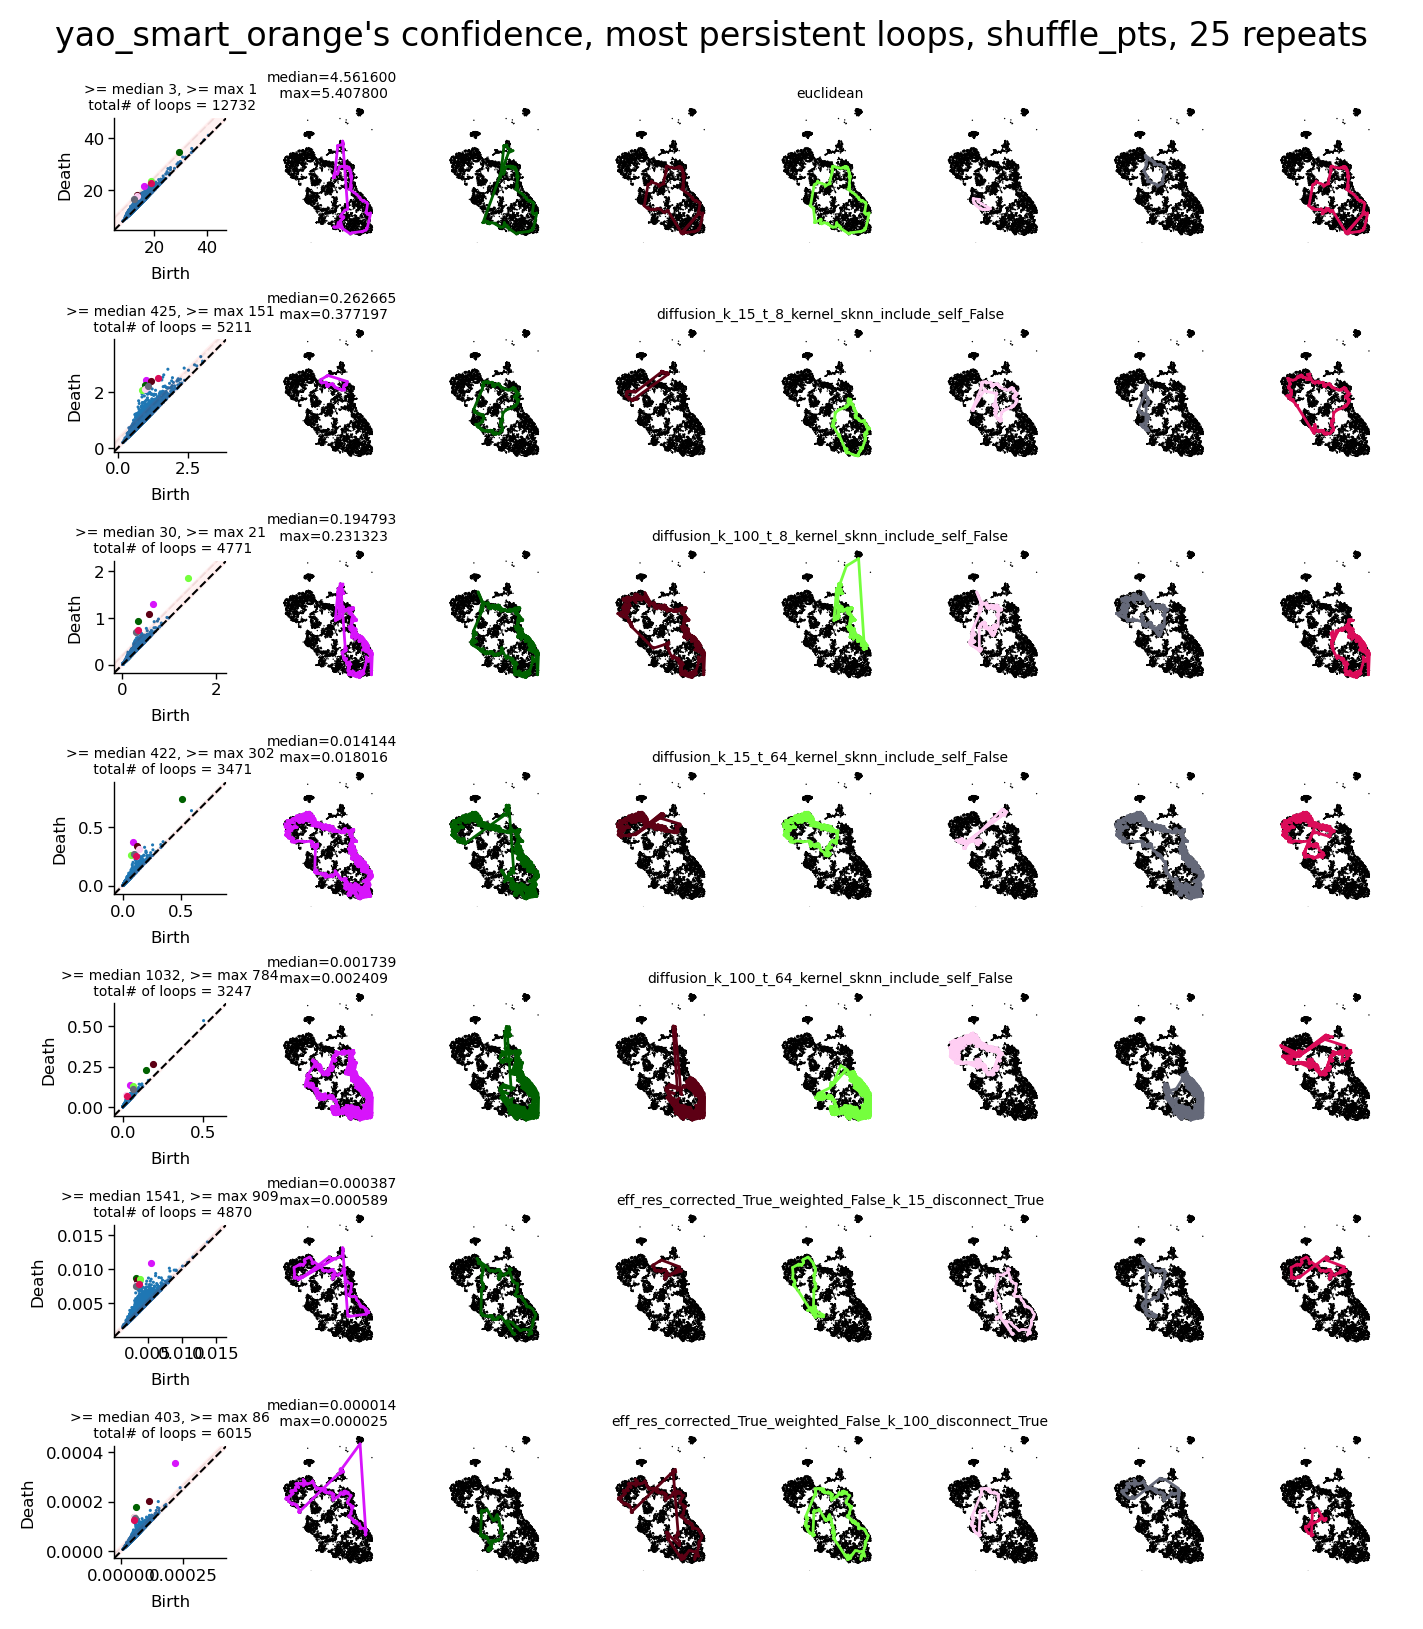

In [ ]:
fig_most_persistent(all_res,  dataset=dataset, embd_n_mask =  embd_smart_orange , method="shuffle_pts", save = True)

## bootstrap

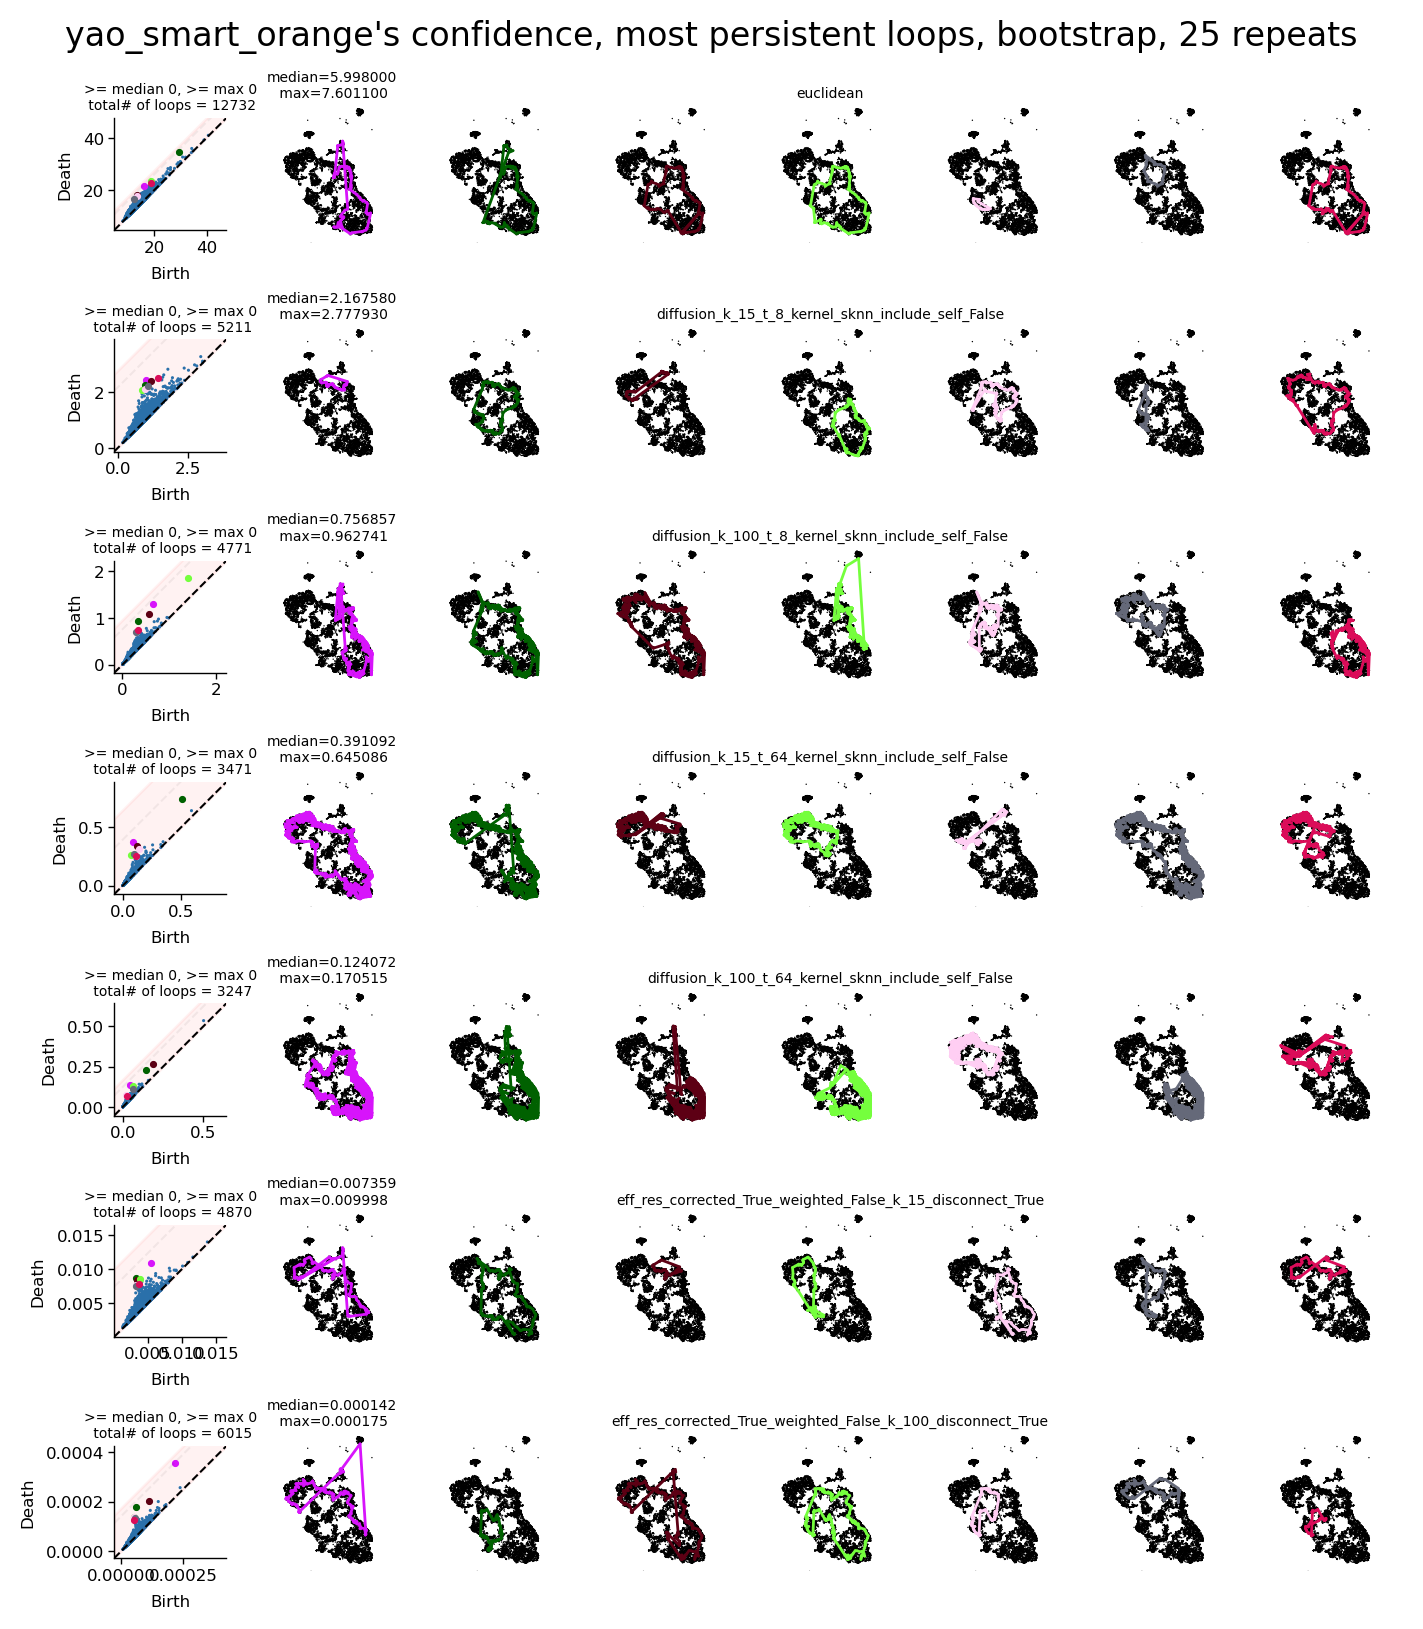

In [ ]:
fig_most_persistent(all_res,  dataset=dataset, embd_n_mask =  embd_smart_orange , method="bootstrap", save = True)

# bottleneck

## shuffle_pts

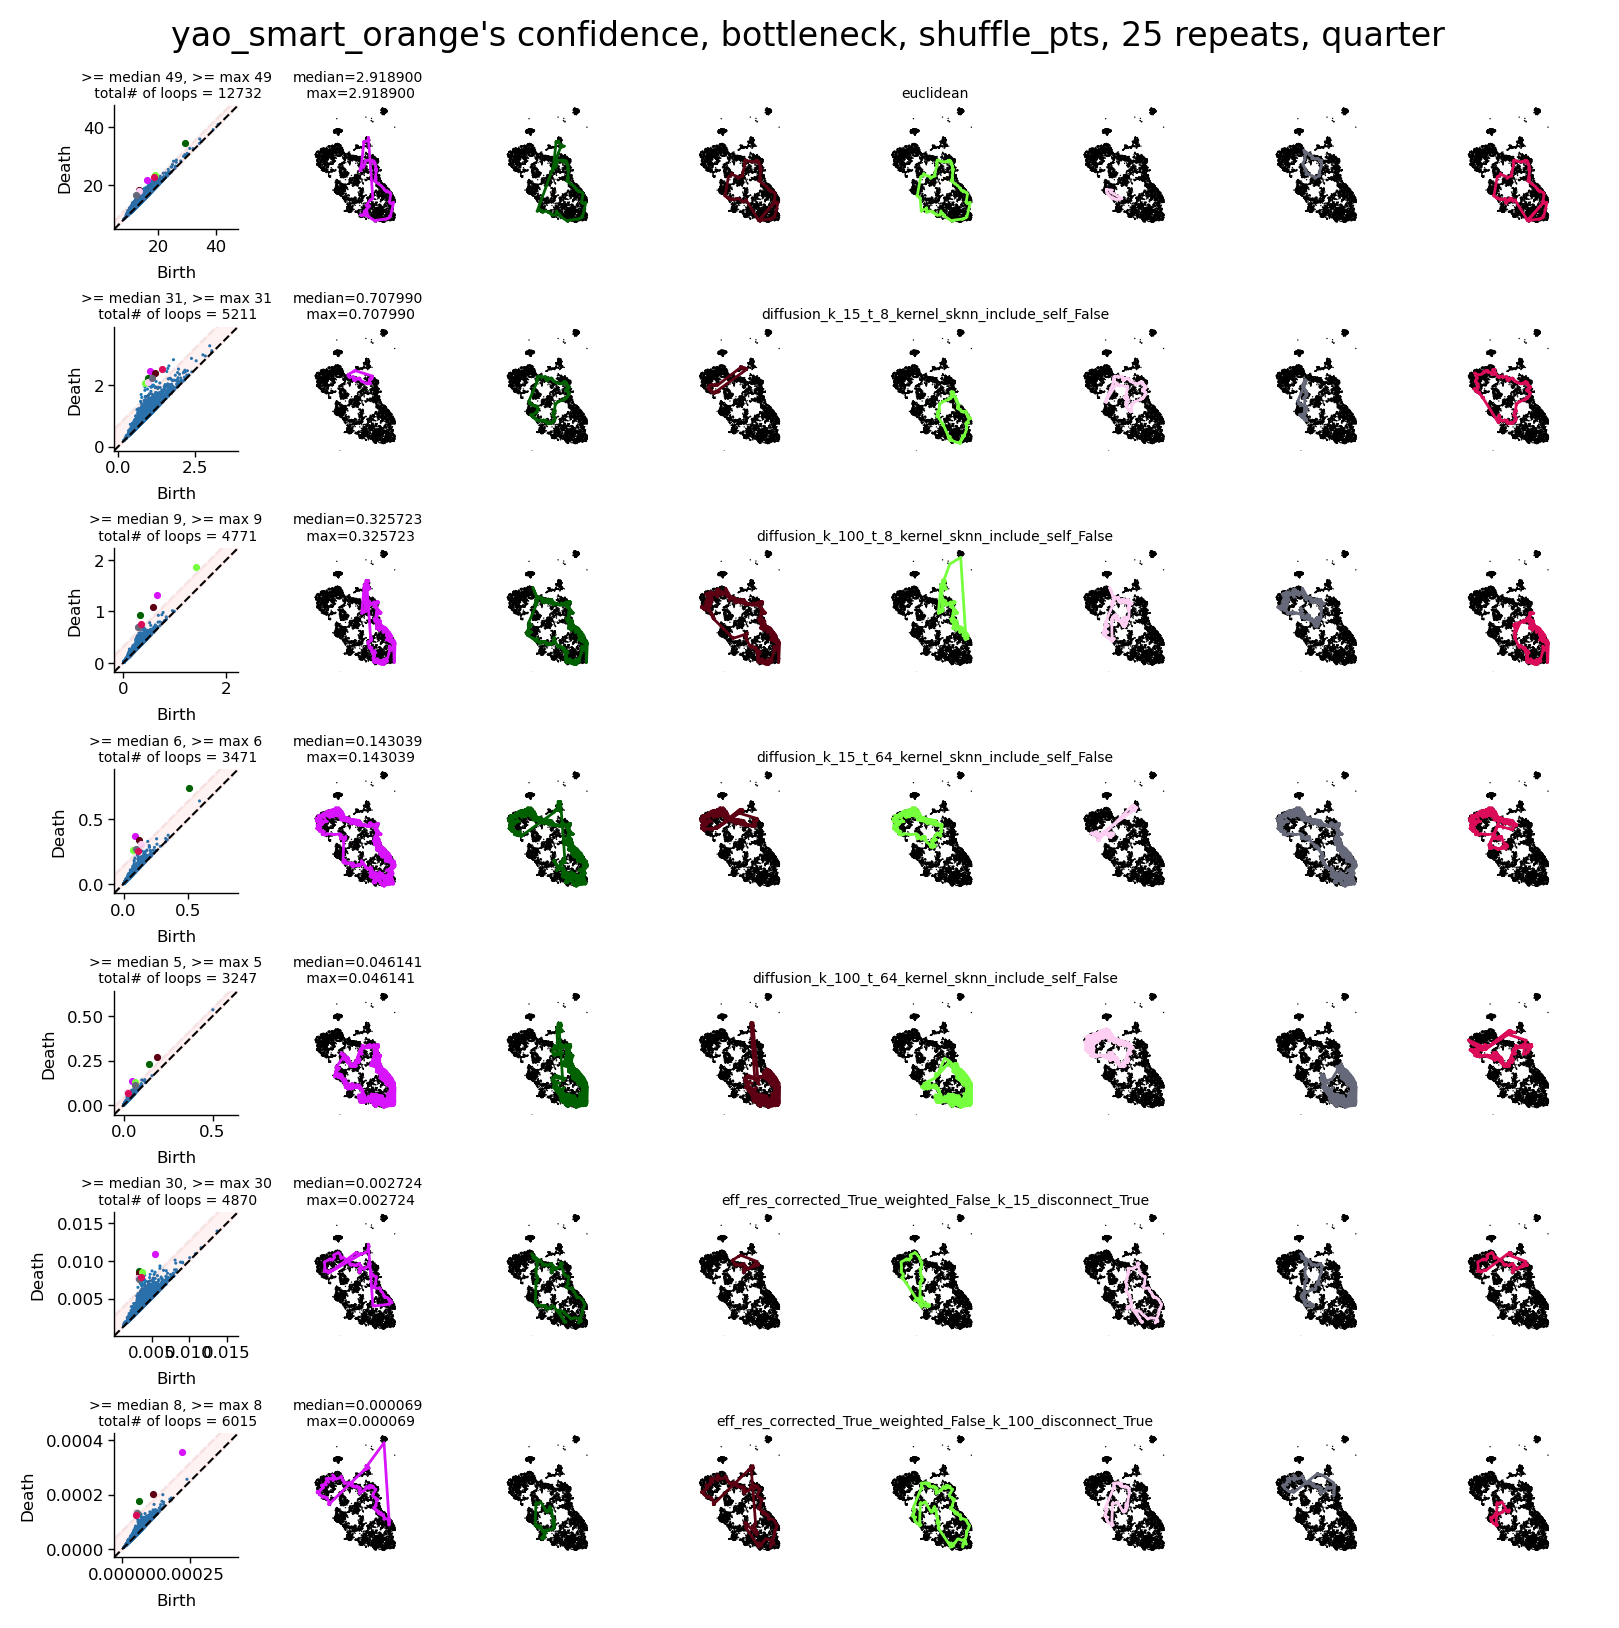

In [ ]:
fig_bottleneck(all_res,  dataset=dataset, embd_n_mask =  embd_smart_orange , method="shuffle_pts", save = True)

## bootstrap

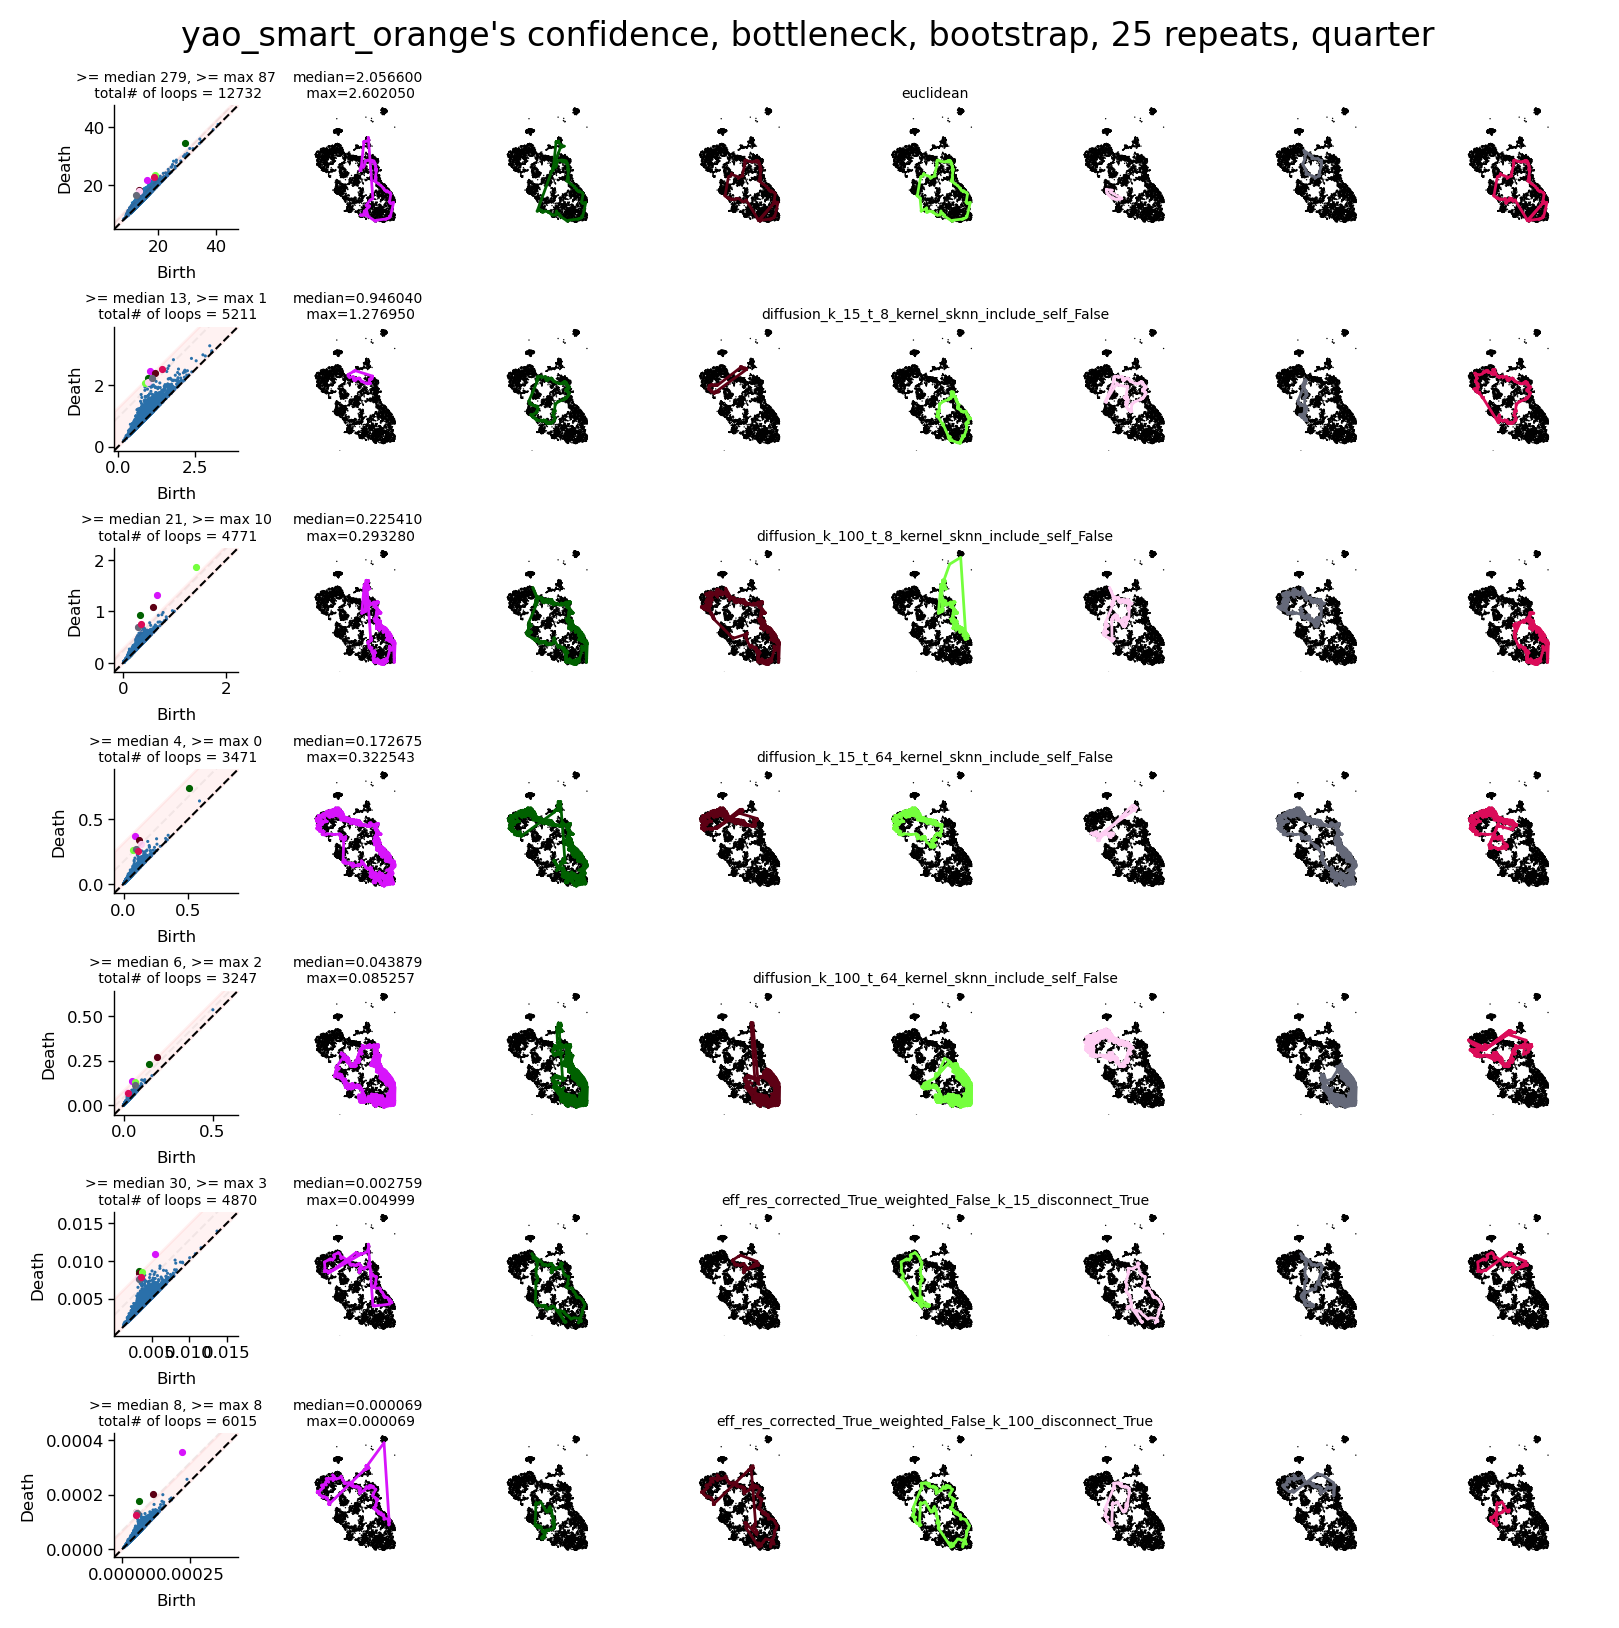

In [ ]:
fig_bottleneck(all_res,  dataset=dataset, embd_n_mask =  embd_smart_orange , method="bootstrap", save = True)

# fig_bottleneck_max of bootstrap

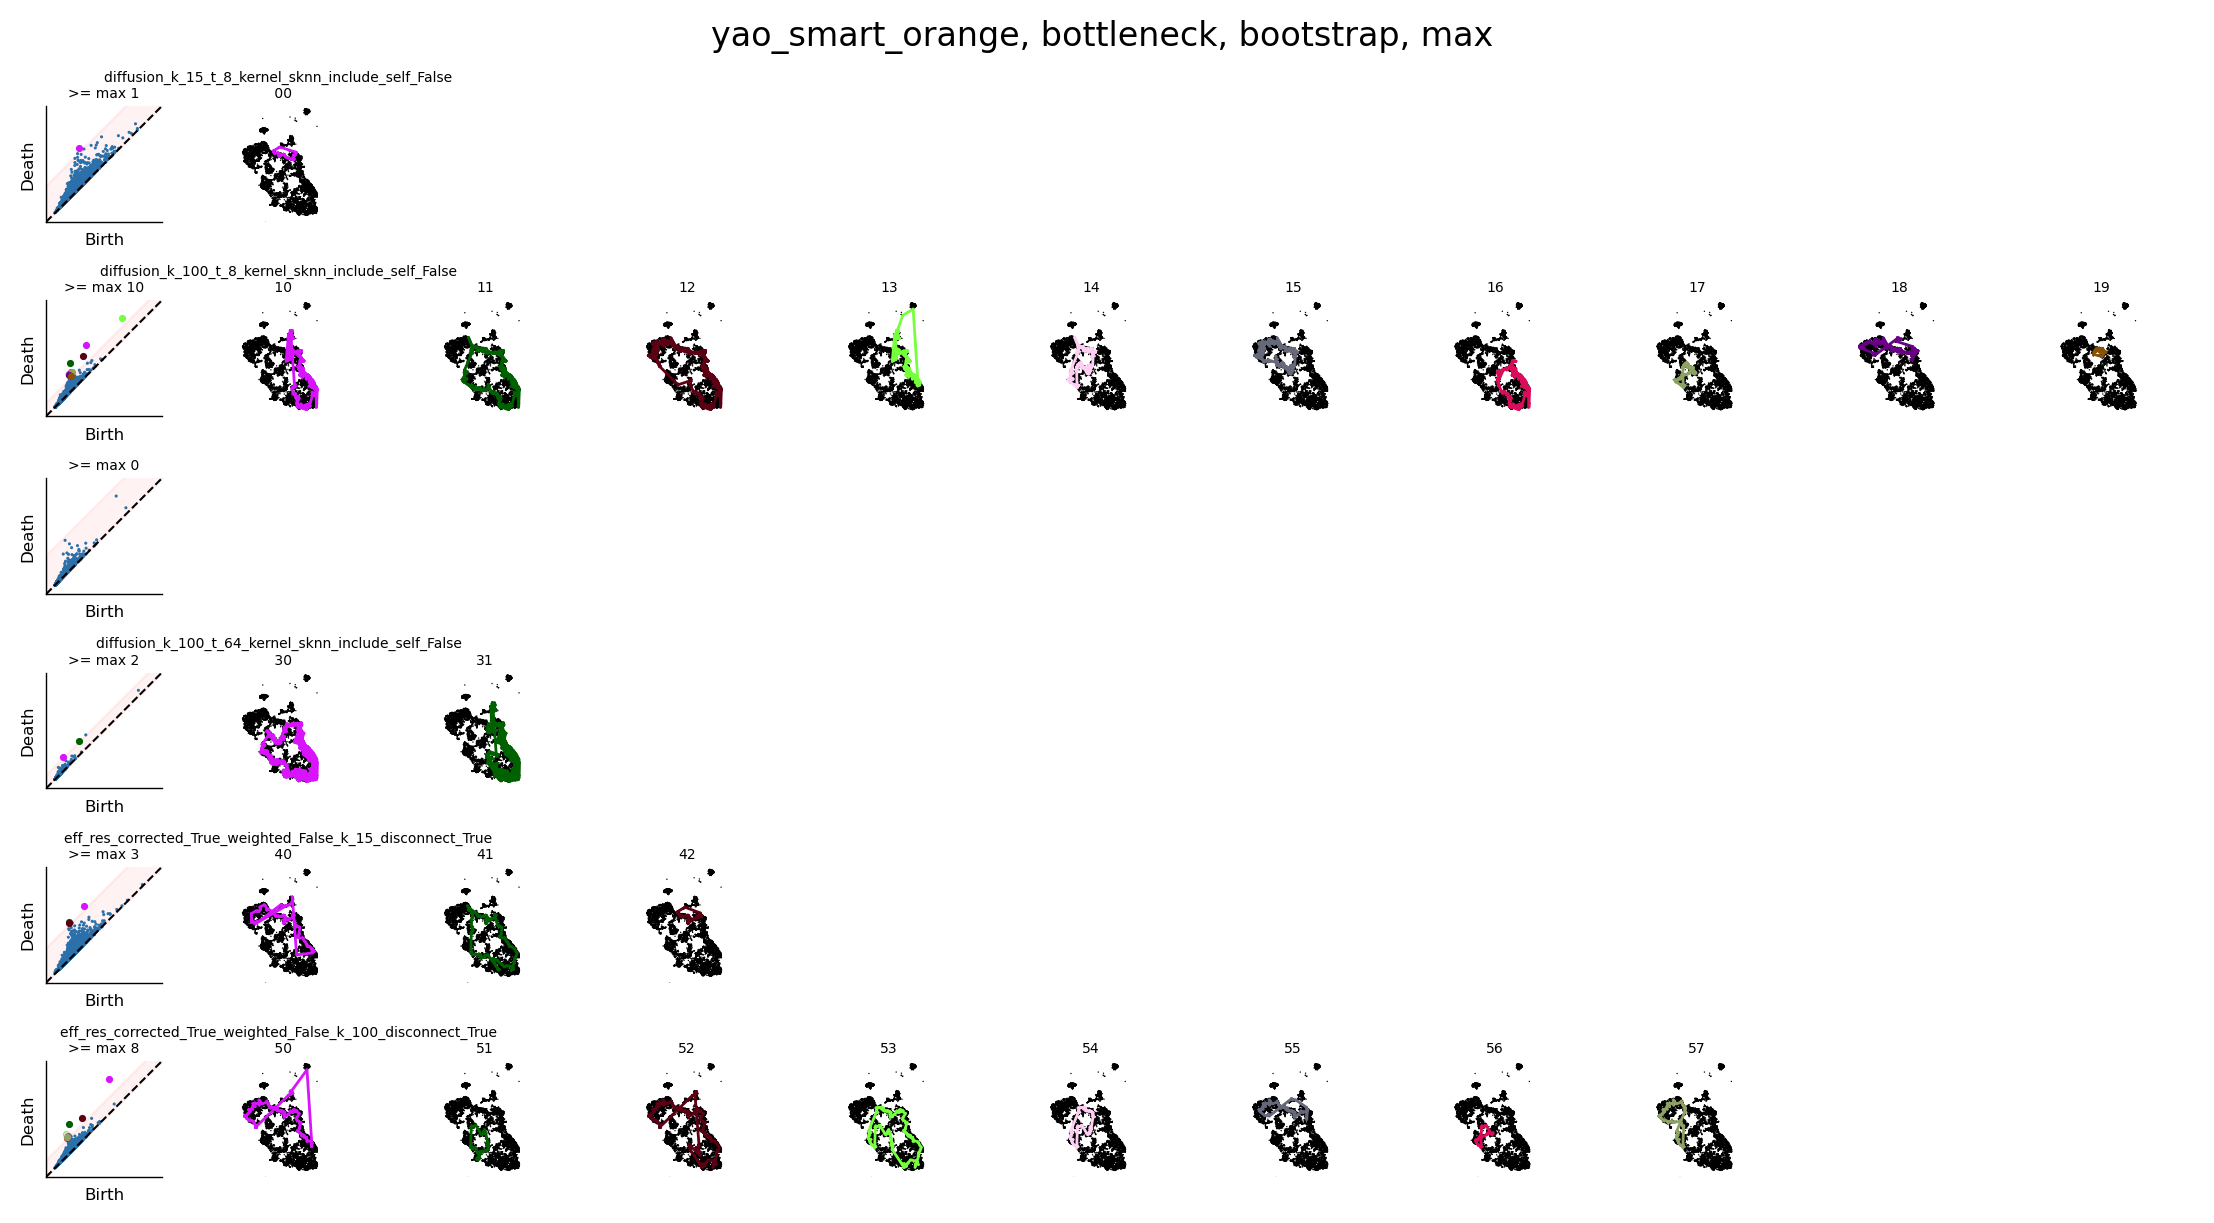

In [ ]:
geq_maxs = fig_bottleneck_max(all_res, dataset=dataset, embd_n_mask =  embd_smart_orange , method="bootstrap", save = True)

# save distribution dist

In [ ]:
_, _, _, _, yao_d = load_dataset(root_path, "yao_smart", k=k)
cluster_orange = [cluster for i, cluster in enumerate(yao_d["clusterNames"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]

In [ ]:
smart_orange_dict = distribution_max(all_res, cell_group_name= "yao_smart_orange", clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)

In [ ]:
save_dict(smart_orange_dict, os.path.join(get_path("data"),"final_dist_bottleneck_max", "dist_smart_orange.pkl"))

# check other parameters of bootstrap + bottleneck

In [ ]:
distances = {
    "diffusion": [
        {"k": 100, "t": 128, "kernel": "sknn", "include_self": False},
        {"k": 200, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 200, "t": 128, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 200, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 300, "disconnect": True},
    ],
}

In [ ]:
dataset = "yao_smart_orange"
x, y, sknn, pca2, d = load_dataset(root_path, dataset, k=k, seed=0)
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)

Done with yao_smart_orange None diffusion_k_100_t_128_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_200_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_200_t_128_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None eff_res_corrected_True_weighted_False_k_200_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_orange None eff_res_corrected_True_weighted_False_k_300_disconnect_True n_outliers=0, perturbation=None


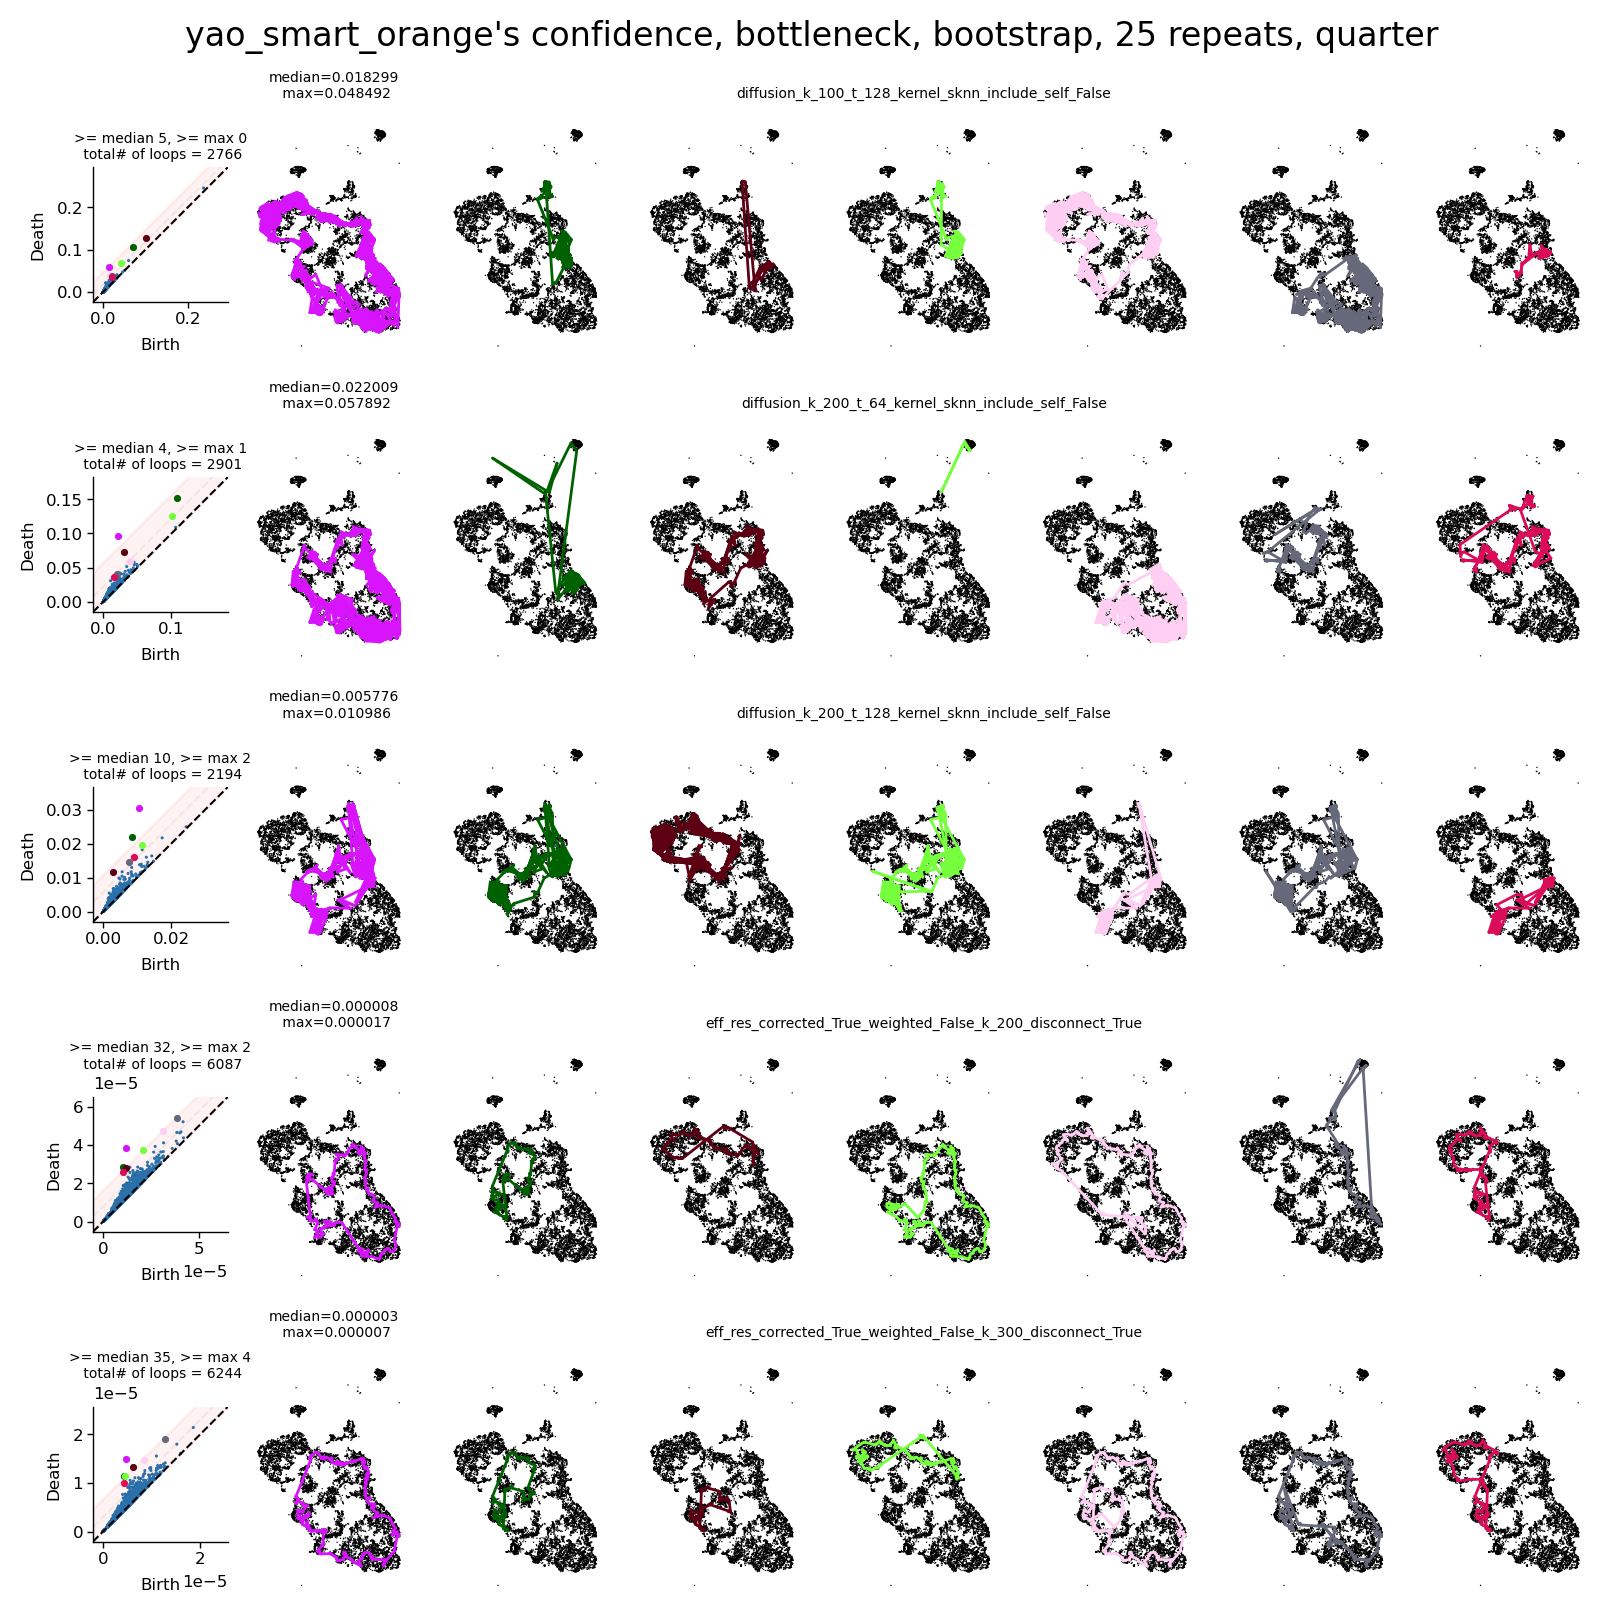

In [ ]:
fig_bottleneck(all_res,  dataset=dataset, embd_n_mask =  embd_smart_orange , method="bootstrap", save =f"Bottleneck_max_{dataset}_bootstrap_parameters")

# fig_bottleneck_median_scale

In [ ]:
dataset = "yao_smart_orange"

_, _, _, _, full_d = load_dataset(root_path, "yao_smart", k=k)
idx_orange = [i for i, cluster in enumerate(full_d["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
cluster_orange = [cluster for i, cluster in enumerate(full_d["clusterNames"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]
mask_orange = [idx in idx_orange for idx in full_d['clusters']]


all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)

Done with yao_smart_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


In [ ]:
get_life_geq_scale(all_res, dataset=dataset, method="bootstrap", ratio = "quarter", scale = 3)

([2.83812,
  0.67623,
  0.5180235,
  0.13163550000000002,
  0.008275500000000002,
  0.0002057955],
 [0, 0, 0, 0, 0, 0])

TypeError: 'Axes' object is not subscriptable

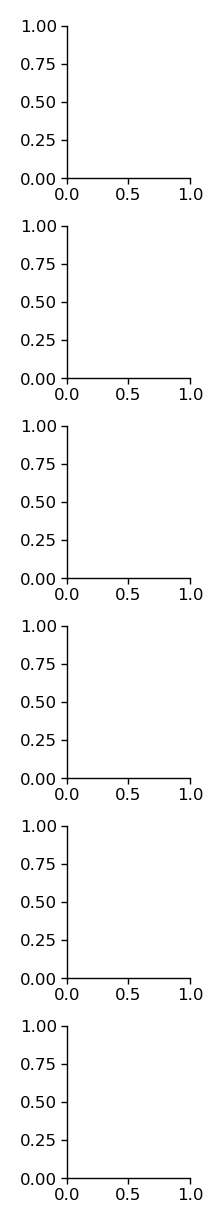

In [ ]:
geq_maxs = fig_bottleneck_median_scale(all_res, dataset=dataset, embd_n_mask =  embd_smart_orange, method="bootstrap", scale = 3, save = False)

print(geq_maxs)
# dist = distribution_max(all_res, cell_group_name= dataset, clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)
# save_dict(dist, os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_tasic_orange_scale_3.pkl"))

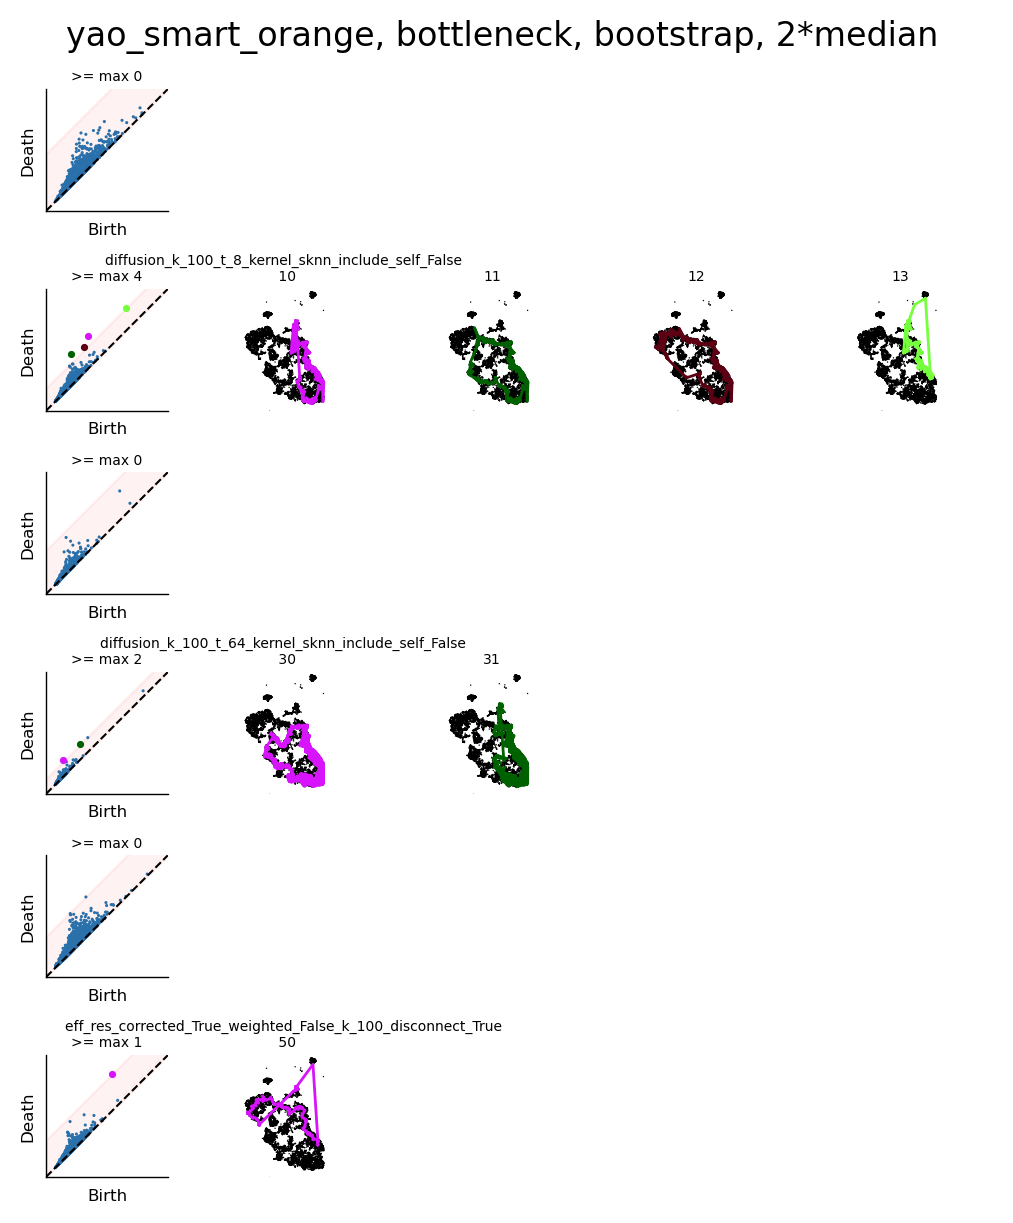

In [ ]:
geq_maxs = fig_bottleneck_median_scale(all_res, dataset=dataset, embd_n_mask =  embd_smart_orange, method="bootstrap", scale = 2, save = False)
dist = distribution_max(all_res, cell_group_name= dataset, clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)
save_dict(dist, os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_smart_orange_scale_2.pkl"))